In [560]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

from pybit.unified_trading import HTTP
from config import API_KEY, API_SECRET, SYMBOL, INTERVAL

In [561]:
session = HTTP(api_key=API_KEY, api_secret=API_SECRET)

In [562]:
def fetch_historical_data(limit=1000):
    klines = session.get_kline(
        category='linear',
        symbol=SYMBOL,
        interval=INTERVAL,
        limit=limit
    )['result']['list']
    
    df = pd.DataFrame(klines, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.astype({
        'open': float, 'high': float, 'low': float,
        'close': float, 'volume': float
    })
    # Sorting before returning
    df = df.sort_values('timestamp', ascending=True)  # Oldest first
    df = df.reset_index(drop=True)
    return df

In [563]:
df = fetch_historical_data()

C:\Users\HP\AppData\Local\Temp\ipykernel_1660\728334553.py:12: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')


In [564]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

In [565]:
df.head(10)

,open,high,low,close,volume,turnover
timestamp,,,,,,
2025-05-12 07:15:00,105586.6,105774.8,105228.3,105422.7,2645.180,278965031.6506
2025-05-12 07:30:00,105422.7,105670.0,104606.8,104699.8,4127.268,433424997.3448
2025-05-12 07:45:00,104699.8,104711.6,104115.7,104434.5,2855.125,298085490.1999
2025-05-12 08:00:00,104434.5,104488.2,104036.7,104268.4,1678.541,175003145.5423
2025-05-12 08:15:00,104268.4,104411.6,104111.8,104271.5,929.887,96956483.7495
2025-05-12 08:30:00,104271.5,104518.2,104199.9,104498.1,628.437,65598690.5919
2025-05-12 08:45:00,104498.1,104721.2,104472.6,104577.5,864.586,90441705.3034
2025-05-12 09:00:00,104577.5,104648.7,104372.2,104380.9,534.676,55869624.4356
2025-05-12 09:15:00,104380.9,104509.2,104346.4,104476.6,372.709,38919542.5566


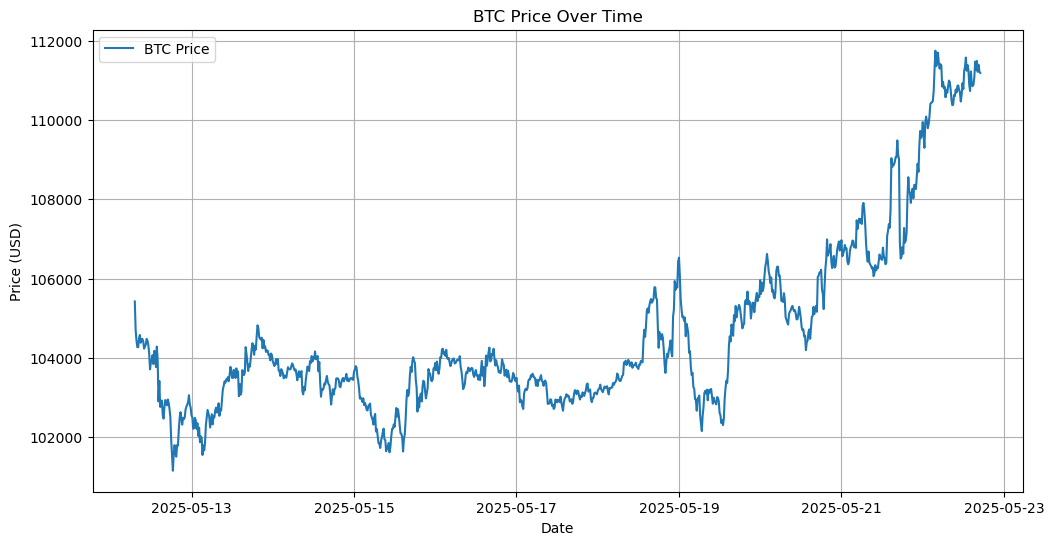

In [566]:
#plot btc price
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='BTC Price')
plt.title('BTC Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()


In [567]:
def bar(x, y):
    return np.int64(x/y)*y

In [568]:
turnover_value = 200000000

# Ensure 'turnover' is numeric
df['turnover'] = pd.to_numeric(df['turnover'], errors='coerce')

dollar_bars = df.groupby(bar(np.cumsum(df['turnover']), turnover_value)).agg({
    'close': 'ohlc',
    'volume': 'sum'
})

# Set the index to the last timestamp of each group using the original index
dollar_bars['bar_timestamp'] = df.groupby(bar(np.cumsum(df['turnover']), turnover_value)).apply(lambda x: x.index[-1])
dollar_bars.set_index('bar_timestamp', inplace=True)
dollar_bars_price = dollar_bars['close']

In [569]:
# Make sure both have datetime index
df = df.sort_index()
dollar_bars = dollar_bars.sort_index()

# Get dollar bars timestamps as intervals
dollar_times = dollar_bars_price.index

# Create intervals between dollar bars
intervals = pd.IntervalIndex.from_tuples([(dollar_times[i], dollar_times[i+1]) 
                                         for i in range(len(dollar_times)-1)], 
                                        closed='left')

# Map each time_bar timestamp to an interval (dollar bar)
df['interval'] = pd.cut(df.index, bins=intervals)

# Sum volume within each interval
vol_sum = df.groupby('interval')['volume'].sum()

# vol_sum.index is a CategoricalIndex, get the IntervalIndex by .categories
interval_index = vol_sum.index.categories  # This is an IntervalIndex

# Now get left endpoints of intervals (start times)
start_times = interval_index.left

# Assign the summed volumes to the dollar bars using start_times as index
dollar_bars_price.loc[start_times, 'volume'] = vol_sum.values

# Forward fill last NaN if needed
dollar_bars_price['volume'] = dollar_bars_price['volume'].ffill()

C:\Users\HP\AppData\Local\Temp\ipykernel_1660\2187993178.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vol_sum = df.groupby('interval')['volume'].sum()


In [570]:
dollar_bars_price.head()

,open,high,low,close,volume
bar_timestamp,,,,,
2025-05-12 07:15:00,105422.7,105422.7,105422.7,105422.7,2645.180
2025-05-12 07:30:00,104699.8,104699.8,104699.8,104699.8,6982.393
2025-05-12 08:00:00,104434.5,104434.5,104268.4,104268.4,2608.428
2025-05-12 08:30:00,104271.5,104498.1,104271.5,104498.1,2400.408
2025-05-12 09:30:00,104577.5,104577.5,104380.9,104477.1,983.436


### Moving Average Model

In [571]:
def getSignal(close, short_window=10, long_window=30):
    
    short_ma = close.rolling(window=short_window).mean()
    long_ma = close.rolling(window=long_window).mean()

    signal = np.where(short_ma > long_ma, 1, -1)
    signal = pd.Series(signal, index=close.index)
    signal[short_ma.isna() | long_ma.isna()] = np.nan  # Remove early NaNs
    return signal.dropna()

### Bollinger Bands Model

In [572]:
def bollinger_bands(close, window=20, num_std=2):
    sma = close.rolling(window).mean()
    std = close.rolling(window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    return lower, sma, upper

lower_band, sma, upper_band = bollinger_bands(dollar_bars_price['close'])

# Generate mean-reversion signals:
# Signal 1 if price crosses below lower band (expect reversion up)
# Signal -1 if price crosses above upper band (expect reversion down)
# 0 otherwise

signal = pd.Series(0, index=dollar_bars_price['close'].index)
signal[dollar_bars_price['close'] < lower_band] = 1
signal[dollar_bars_price['close'] > upper_band] = -1
signal = signal[signal != 0]

In [573]:
def getDailyVol(close, span0=100):
    daily_ret = close.pct_change()
    daily_vol = daily_ret.ewm(span=span0).std()
    return daily_vol

In [574]:
target = getDailyVol(dollar_bars_price['close'])

In [575]:
def getEvents(close, tEvents, ptSl, target, minRet, numThreads=1, t1=False):

    # Subset target where return exceeds minRet
    trgt = target.loc[tEvents]
    trgt = trgt[trgt > minRet]

    # Create event dict
    events = pd.DataFrame(index=trgt.index)
    if t1 is False:
        t1 = pd.Series(pd.NaT, index=trgt.index)
    events['t1'] = t1.loc[trgt.index]
    events['trgt'] = trgt
    events['side'] = 1  # long-only

    return events

In [576]:
def symmetricCUMSUMfilter(close):
    
    # Compute daily returns
    daily_ret = close.pct_change().dropna()

    # Compute threshold as standard deviation of daily returns
    h = daily_ret.std()

    # Initialize variables
    tEvents = []
    sPos, sNeg = 0, 0

    # Apply CUSUM filter
    for i in daily_ret.index:
        r = daily_ret.loc[i]
        sPos = max(0, sPos + r)
        sNeg = min(0, sNeg + r)
        if sPos > h:
            sPos = 0
            tEvents.append(i)
        elif sNeg < -h:
            sNeg = 0
            tEvents.append(i)

    return pd.DatetimeIndex(tEvents)

tevents = symmetricCUMSUMfilter(dollar_bars_price['close'])

In [577]:
def addVerticalBarrier(tEvents, close, numDays=1):
    t1 = {}
    for t in tEvents:
        dt = t + pd.Timedelta(days=numDays)
        t1[t] = close.index[close.index.searchsorted(dt)] if dt <= close.index[-1] else pd.NaT
    return pd.Series(t1)

t1 = addVerticalBarrier(tevents, dollar_bars_price['close'])

In [578]:
ptSl = [0.2, 0.2]  # profit-taking and stop-loss at 1x target volatility
minRet = 0.002  # minimum return required to trade

# Signal for Moving Average model
signal = getSignal(dollar_bars_price['close'])
events = getEvents(dollar_bars_price['close'], tevents, ptSl, target, minRet=minRet, t1=t1)

# Align signals to events
events = events.loc[events.index.intersection(signal.index)]
events['side'] = signal.loc[events.index]

In [579]:
def applyPtSlOnT1(close, events, ptSl, molecule):
   
    out = events.loc[molecule].copy()
    pt = ptSl[0]
    sl = ptSl[1]
    
    for loc, event in out.iterrows():
        df0 = close[loc:event['t1']]  # path prices
        df0 = (df0 / close[loc] - 1) * event['side']  # returns
        out.loc[loc, 'sl'] = df0[df0 < -sl * event['trgt']].index.min()
        out.loc[loc, 'pt'] = df0[df0 > pt * event['trgt']].index.min()
    return out

def getBins(events, close):

    events_ = events.dropna(subset=['t1'])
    out = events_[['t1']].copy(deep=True)

    for loc, t1 in events_['t1'].items():
        # Get path between event start and vertical barrier
        path = close[loc:t1]
        ret = (path.iloc[-1] / close[loc] - 1) * events_.at[loc, 'side']
        out.loc[loc, 'ret'] = ret

        pt = events_.at[loc, 'pt']
        sl = events_.at[loc, 'sl']

        # Identify the earliest event (among pt, sl, t1)
        first_touch = {pt: 1, sl: -1, t1: 0}
        min_time = min([x for x in [pt, sl, t1] if pd.notna(x)])

        # Assign label based on first touched barrier
        out.loc[loc, 'bin'] = first_touch.get(min_time, 0)

    return out

In [580]:
outcomes = applyPtSlOnT1(dollar_bars_price['close'], events, ptSl, events.index)

# Merge outcome times into event DataFrame
events['pt'] = outcomes['pt']
events['sl'] = outcomes['sl']

labels = getBins(events, dollar_bars_price['close'])

In [581]:
def dropLabels(labels, minPct=0.05):
   
    # Count label frequencies
    df0 = labels['bin'].value_counts(normalize=True)
    
    # Keep only labels that appear more than `minPct`
    labels_to_keep = df0[df0 > minPct].index
    
    # Filter
    return labels[labels['bin'].isin(labels_to_keep)]

labels_filtered = dropLabels(labels, minPct=0.05)

In [582]:
labels_filtered.head()

,t1,ret,bin
2025-05-12 20:30:00,2025-05-13 21:00:00,-0.017129,1.0
2025-05-12 22:15:00,2025-05-13 22:45:00,-0.013391,-1.0
2025-05-12 23:15:00,2025-05-14 00:00:00,-0.008266,1.0
2025-05-13 00:00:00,2025-05-14 00:00:00,-0.013282,1.0
2025-05-13 00:45:00,2025-05-14 01:00:00,-0.017046,-1.0


In [583]:
X = pd.DataFrame(index=labels_filtered.index)
X['ret_15min'] = dollar_bars_price['close'].pct_change(1)
X['ret_1h'] = dollar_bars_price['close'].pct_change(4)  # 4 x 15-min bars
X['ret_4h'] = dollar_bars_price['close'].pct_change(16)
X['vol_1h'] = target.loc[labels_filtered.index]
X['ret_1h_norm'] = X['ret_1h'] / X['vol_1h']
X['side'] = events['side'].loc[labels_filtered.index]

In [584]:
X = X.dropna()
labels_filtered = labels_filtered.loc[X.index]
y = labels_filtered['bin']  # or binary meta-label 0/1

In [585]:
X.head()

,ret_15min,ret_1h,ret_4h,vol_1h,ret_1h_norm,side
2025-05-12 20:30:00,0.006833,0.013136,-0.004046,0.003927,3.344983,-1.0
2025-05-12 22:15:00,0.003756,0.010750,-0.000597,0.003875,2.774266,-1.0
2025-05-12 23:15:00,0.003477,0.012479,0.001548,0.003881,3.215158,-1.0
2025-05-13 00:00:00,-0.004951,0.000629,-0.003661,0.003905,0.161170,-1.0
2025-05-13 00:45:00,-0.003118,-0.000865,-0.002349,0.003858,-0.224182,-1.0


In [586]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [587]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [588]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.55      0.64      0.59        25
         1.0       0.36      0.28      0.31        18

    accuracy                           0.49        43
   macro avg       0.45      0.46      0.45        43
weighted avg       0.47      0.49      0.48        43



### Bollinger Bands Model

In [589]:
def bollinger_bands(close, window=20, num_std=2):
    sma = close.rolling(window).mean()
    std = close.rolling(window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    return lower, sma, upper

lower_band, sma, upper_band = bollinger_bands(dollar_bars_price['close'])

# Generate mean-reversion signals:
# Signal 1 if price crosses below lower band (expect reversion up)
# Signal -1 if price crosses above upper band (expect reversion down)
# 0 otherwise

signal = pd.Series(0, index=dollar_bars_price['close'].index)
signal[dollar_bars_price['close'] < lower_band] = 1
signal[dollar_bars_price['close'] > upper_band] = -1
signal = signal[signal != 0]

In [590]:
target = getDailyVol(dollar_bars_price['close'])

# Generate event timestamps when signal changes (crosses bands)
events = pd.DataFrame(index=signal.index)
events['side'] = signal


In [591]:
# Create vertical barriers 1 day after event timestamp
numDays = 1
tevents = symmetricCUMSUMfilter(dollar_bars_price['close'])
t1 = addVerticalBarrier(tevents, dollar_bars_price['close'])  # or use your vertical barrier function to generate t1

events['t1'] = events.index + pd.Timedelta(days=numDays)
events.loc[events['t1'] > dollar_bars_price['close'].index[-1], 't1'] = dollar_bars_price['close'].index[-1]  # cap t1 at last index

# set profit-taking and stop-loss levels
ptSl = [0, 2] 

# Ensure events has 'trgt' column
events['trgt'] = target.loc[events.index]
# Apply triple barrier method to get pt (profit taking), sl (stop loss) and outcomes
outcomes = applyPtSlOnT1(dollar_bars_price['close'], events, ptSl, molecule=events.index)

# Merge only 'pt' and 'sl' columns from outcomes to events to avoid column overlap error
events = events.join(outcomes[['pt', 'sl']])

# Compute meta-labels with getBins (adjusted to assign 0 if vertical barrier touched first)
labels = getBins(events, dollar_bars_price['close'])

labels_filtered = dropLabels(labels, minPct=0.05)

In [592]:
# Volatility: use daily_vol shifted to avoid lookahead bias
features = pd.DataFrame(index=dollar_bars_price['close'].index)
features['volatility'] = target.shift(1)

# Serial correlation (autocorrelation of returns over last 5 bars)
returns = dollar_bars_price['close'].pct_change()
features['serial_corr'] = returns.rolling(window=5).apply(lambda x: x.autocorr(), raw=False).shift(1)

# Moving averages from exercise 2
short_window = 10
long_window = 30
short_ma = dollar_bars_price['close'].rolling(short_window).mean()
long_ma = dollar_bars_price['close'].rolling(long_window).mean()
features['ma_crossover'] = np.where(short_ma > long_ma, 1, -1)
features['ma_crossover'] = features['ma_crossover'].shift(1)


features = features.dropna()

In [593]:
df = features.join(labels['bin'].rename('label'), how='inner').dropna()

X = df[['volatility', 'serial_corr', 'ma_crossover']]
y = df['label']

In [594]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [595]:
from sklearn.metrics import classification_report

# Primary model accuracy on trade decision (trade or not = signal != 0)
y_primary = (df.loc[X_test.index, 'label'] != 0).astype(int)

print("Primary Model Classification Report")
print(classification_report(y_test, y_primary))

Primary Model Classification Report
              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         3
         1.0       0.77      1.00      0.87        10

    accuracy                           0.77        13
   macro avg       0.38      0.50      0.43        13
weighted avg       0.59      0.77      0.67        13



c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [596]:
print("Secondary Model Classification Report")
print(classification_report(y_test, y_pred))

Secondary Model Classification Report
              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00         3
         1.0       0.77      1.00      0.87        10

    accuracy                           0.77        13
   macro avg       0.38      0.50      0.43        13
weighted avg       0.59      0.77      0.67        13



c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3.1\envs\DM2425\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
